# Modul 1: Fondasi Jaringan Saraf, FNN, Aktivasi, dan Loss

**Nama:** Oktavia Nurwenda puspita Sari
**NIM:** 122450041
**Kelas:** RA
**Tanggal:** 21-09-2026

**Berkas pengumpulan:** `M01_NIM.ipynb`, `M01_NIM.pdf`, dan `M01_NIM_metrics.csv`.

> Seluruh kode, eksperimen, grafik, dan analisis merupakan pekerjaan individual. Beri atribusi pada kode yang diadaptasi dari sumber lain.

## Petunjuk

1. Ganti seluruh penanda `TODO`.
2. Jangan mengubah protokol eksperimen kecuali diminta.
3. Gunakan validation set untuk memilih model. Test set hanya untuk model final.
4. Sebelum mengumpulkan, jalankan **Restart Kernel and Run All**.
5. Pertahankan semua hasil eksperimen, termasuk hasil yang tidak sesuai hipotesis.

In [2]:
import platform
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.datasets import make_moons
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

NIM = '122450041'  # TODO: ganti dengan NIM lengkap
assert NIM.isdigit() and len(NIM) >= 4, 'Isi NIM dengan angka sebelum melanjutkan.'
NIM_LAST4 = int(NIM[-4:])           # 41
SEED = 1000 + NIM_LAST4             # 1041
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'sklearn': sklearn.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

{'python': '3.13.15',
 'numpy': '2.1.3',
 'pandas': '2.2.3',
 'sklearn': '1.6.1',
 'torch': '2.11.0+cpu',
 'device': 'cpu',
 'seed': 1041}

## A. Pre-lab - 10 poin

> Tambahkan blockquote



Jawab sebelum sesi praktikum.

1. **Parameter vs hyperparameter:** TODO
2. **Mengapa tumpukan layer affine tanpa aktivasi dapat diciutkan:** TODO
3. **Shape bobot layer 2 masukan -> 8 keluaran:** TODO
4. **Mengapa `BCEWithLogitsLoss` menerima logit:** TODO

### Hipotesis awal

Prediksi aktivasi dan hidden size yang akan memberi validation loss terbaik. Jelaskan alasannya sebelum menjalankan eksperimen.

**Jawaban:** TODO

## A. Pre-lab - 10 poin

Jawab sebelum sesi praktikum.

1. **Parameter vs hyperparameter:**
   - **Parameter** adalah nilai yang dipelajari model dari data, yaitu bobot (`W`) dan bias (`b`) pada setiap layer. Nilainya diperbarui oleh optimizer melalui gradient descent.
   - **Hyperparameter** adalah nilai yang ditetapkan sebelum training dan tidak diubah oleh optimizer, misalnya learning rate, jumlah epoch, hidden size, jenis aktivasi, dan batch size.

2. **Mengapa tumpukan layer affine tanpa aktivasi dapat diciutkan:**
   Karena komposisi fungsi linear tetap linear. Untuk dua layer affine berturut-turut berlaku
   $W_2(W_1 x + b_1) + b_2 = (W_2 W_1)\,x + (W_2 b_1 + b_2)$,
   sehingga keduanya setara dengan satu layer affine dengan bobot $W = W_2 W_1$ dan bias $b = W_2 b_1 + b_2$. Tanpa non-linearitas, menambah kedalaman tidak menambah kapasitas representasi.

3. **Shape bobot layer 2 masukan -> 8 keluaran:**
   `nn.Linear(2, 8)` memiliki `weight.shape = (8, 2)` dan `bias.shape = (8,)`. Total parameter = $8 \times 2 + 8 = 24$.

4. **Mengapa `BCEWithLogitsLoss` menerima logit:**
   Karena sigmoid dan BCE digabung dengan *log-sum-exp trick* sehingga secara numerik lebih stabil:
   $\text{BCEWithLogits}(z, y) = \max(z, 0) - z y + \log\!\left(1 + e^{-|z|}\right)$.
   Cara ini menghindari overflow/underflow yang muncul bila sigmoid dihitung lebih dulu lalu di-`log`. Konsekuensinya, output model harus berupa **logit mentah** tanpa sigmoid di akhir.

### Hipotesis awal

Prediksi aktivasi dan hidden size yang akan memberi validation loss terbaik. Jelaskan alasannya sebelum menjalankan eksperimen.

**Jawaban:**
Saya memprediksi kombinasi **ReLU dengan hidden size 16** akan memberi validation loss terbaik. Alasannya:
- ReLU tidak jenuh pada nilai positif sehingga gradien tetap besar dan konvergensi cepat dengan SGD.
- Hidden size 16 memberi kapasitas lebih untuk melengkungnya decision boundary pada dataset `make_moons` yang tidak linearly separable.
- Tanh diperkirakan kompetitif karena outputnya berpusat di nol (membantu optimisasi), tetapi sedikit lebih lambat karena saturasi pada |z| besar.
- Sigmoid diprediksi paling lambat konvergen dan paling rentan jenuh, terutama pada hidden size besar.

## B. Neuron dan fungsi aktivasi dengan NumPy - 20 poin

In [3]:
def sigmoid_np(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=np.float64)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

def relu_np(z: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, np.asarray(z, dtype=np.float64))

def leaky_relu_np(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    z = np.asarray(z, dtype=np.float64)
    return np.where(z > 0, z, alpha * z)

def neuron_batch(X: np.ndarray, w: np.ndarray, b: float, activation):
    X = np.asarray(X, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64)
    assert X.ndim == 2, 'X harus 2D (n_samples, n_features)'
    assert w.ndim == 1, 'w harus 1D (n_features,)'
    assert X.shape[1] == w.shape[0], f'Dimensi tidak cocok: {X.shape} vs {w.shape}'
    z = X @ w + b
    a = activation(z)
    return z, a
# Uji minimum - jangan mengubah data uji.
X_check = np.array([[2.0, -1.0], [0.0, 3.0], [-2.0, 1.0]])
w_check = np.array([0.5, -0.5])
z_check, a_check = neuron_batch(X_check, w_check, 0.25, sigmoid_np)
assert z_check.shape == (3,)
assert a_check.shape == (3,)
assert np.all(np.isfinite(a_check))
assert np.all((a_check > 0) & (a_check < 1))
pd.DataFrame({'z': z_check, 'sigmoid(z)': a_check})

,z,sigmoid(z)
0,1.75,0.8520
1,-1.25,0.2227
2,-1.25,0.2227


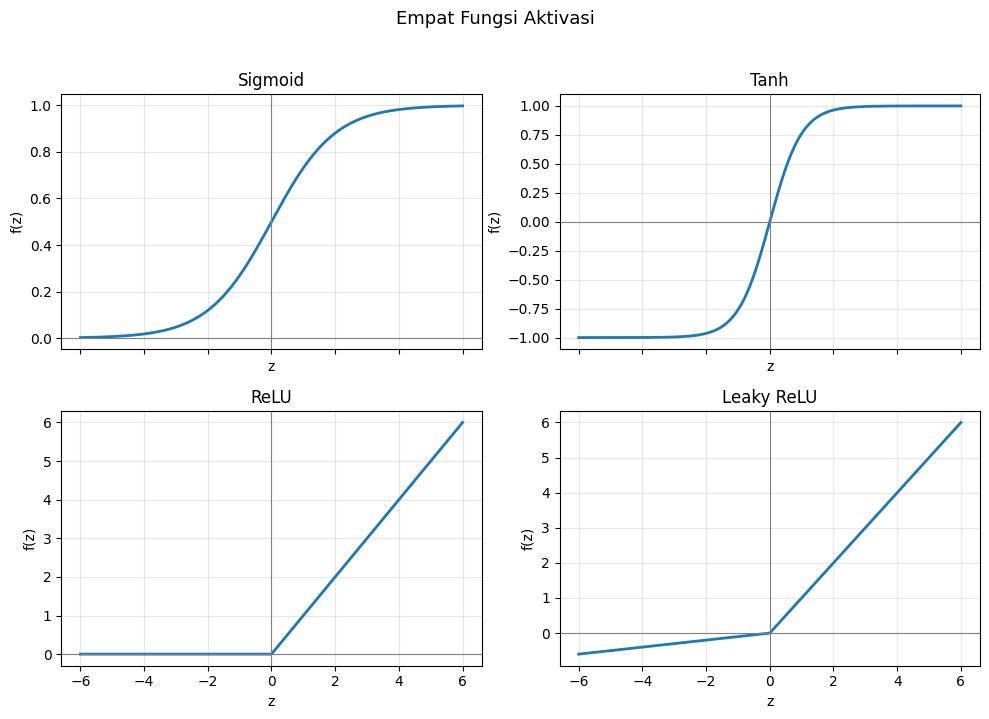

In [4]:
grid = np.linspace(-6, 6, 600)
# TODO: lengkapi kamus dengan empat aktivasi.
activation_values = {
    'Sigmoid':    sigmoid_np(grid),
    'Tanh':       np.tanh(grid),
    'ReLU':       relu_np(grid),
    'Leaky ReLU': leaky_relu_np(grid, alpha=0.1),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
for ax, (name, values) in zip(axes.ravel(), activation_values.items()):
    ax.plot(grid, values, color='tab:blue', lw=2)
    ax.axhline(0, color='gray', lw=0.8)
    ax.axvline(0, color='gray', lw=0.8)
    ax.set_title(name)
    ax.set_xlabel('z')
    ax.set_ylabel('f(z)')
    ax.grid(alpha=0.3)
fig.suptitle('Empat Fungsi Aktivasi', y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

### Interpretasi aktivasi

- **Aktivasi yang berpusat di nol:** **Tanh** (dan sebagian **Leaky ReLU**). Output tanh berkisar di $(-1, 1)$ dengan $\tanh(0) = 0$, sehingga rata-rata aktivasi mendekati nol dan membantu mengurangi *zig-zag* pada gradient descent. Sigmoid dan ReLU tidak berpusat di nol.

- **Aktivasi yang tepat nol untuk masukan negatif:** **ReLU**, karena $f(z) = \max(0, z) = 0$ untuk semua $z < 0$. Akibatnya banyak neuron bisa "mati" (dying ReLU) bila gradiennya nol terus.

- **Aktivasi yang mudah jenuh:** **Sigmoid** dan **Tanh**. Untuk $|z|$ besar, turunannya menuju nol ($\sigma'(z) \to 0$ dan $\tanh'(z) \to 0$), sehingga gradien yang mengalir ke layer awal menjadi sangat kecil → *vanishing gradient*.

- **Mengapa aktivasi linear tidak cukup untuk `make_moons`:** Karena `make_moons` tidak *linearly separable*. Komposisi fungsi linear tetap linear, sehingga decision boundary yang bisa dihasilkan selalu berupa garis lurus. Non-linearitas (ReLU/Tanh/Sigmoid) diperlukan agar jaringan dapat membentuk batas keputusan melengkung yang memisahkan dua bulan sabit.

## C. Forward pass manual - bagian dari 20 poin pemetaan

Gunakan arsitektur $2 \rightarrow 2 \rightarrow 1$, ReLU pada hidden layer, dan target $y=1$. Jangan mengubah bobot.

In [9]:
x_manual = np.array([[2.0, -1.0]], dtype=np.float32)
W1 = np.array([[0.5, -0.5], [1.0, 1.0]], dtype=np.float32)
b1 = np.array([0.0, 0.0], dtype=np.float32)
W2 = np.array([[2.0, -1.0]], dtype=np.float32)
b2 = np.array([0.5], dtype=np.float32)
y_manual = np.array([[1.0]], dtype=np.float32)

z1_np    = x_manual @ W1.T + b1                 # [[0., -2.]]
h_np     = relu_np(z1_np).astype(np.float32)    # [[0., 0.]]
logit_np = h_np @ W2.T + b2                     # [[0.5]]
prob_np  = sigmoid_np(logit_np).astype(np.float32)
bce_np   = -np.mean(
    y_manual * np.log(prob_np + 1e-12) +
    (1 - y_manual) * np.log(1 - prob_np + 1e-12)
)

parameter_count_manual = (
    W1.size + b1.size + W2.size + b2.size       # 4 + 2 + 2 + 1 = 9
)

pd.DataFrame({
    'z1': z1_np.ravel(),
    'h':  h_np.ravel(),
})
print('logit =', logit_np, 'prob =', prob_np, 'BCE =', bce_np,
      'params =', parameter_count_manual)

logit = [[2.5]] prob = [[0.9241418]] BCE = 0.078889735 params = 9


### Tabel shape dan nilai

| Tensor | Shape | Nilai |
|---|---:|---:|
| $x$ | TODO | TODO |
| $W^{(1)}$ | TODO | tersedia pada kode |
| $z^{(1)}$ | TODO | TODO |
| $h$ | TODO | TODO |
| logit | TODO | TODO |
| probabilitas | TODO | TODO |
| BCE | skalar | TODO |

**Jumlah parameter dan perhitungannya:** TODO

## D. Pencocokan NumPy dan PyTorch - 20 poin

Salin bobot ke `nn.Sequential`. Jangan menambahkan sigmoid ke model karena loss menerima logit.

In [10]:
# --- Variabel dari Bagian C (diulang agar sel D mandiri) ---
x_manual = np.array([[2.0, -1.0]], dtype=np.float32)
W1 = np.array([[0.5, -0.5], [1.0, 1.0]], dtype=np.float32)
b1 = np.array([0.0, 0.0], dtype=np.float32)
W2 = np.array([[2.0, -1.0]], dtype=np.float32)
b2 = np.array([0.5], dtype=np.float32)
y_manual = np.array([[1.0]], dtype=np.float32)

z1_np    = x_manual @ W1.T + b1
h_np     = relu_np(z1_np).astype(np.float32)
logit_np = h_np @ W2.T + b2
prob_np  = sigmoid_np(logit_np).astype(np.float32)
bce_np   = -np.mean(
    y_manual * np.log(prob_np + 1e-12) +
    (1 - y_manual) * np.log(1 - prob_np + 1e-12)
)
parameter_count_manual = W1.size + b1.size + W2.size + b2.size   # = 9

# --- Bagian D ---
manual_model = nn.Sequential(
    nn.Linear(2, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
)

with torch.no_grad():
    manual_model[0].weight.copy_(torch.from_numpy(W1))
    manual_model[0].bias.copy_(torch.from_numpy(b1))
    manual_model[2].weight.copy_(torch.from_numpy(W2))
    manual_model[2].bias.copy_(torch.from_numpy(b2))

manual_model.eval()
x_t = torch.from_numpy(x_manual)
y_t = torch.from_numpy(y_manual)
with torch.no_grad():
    torch_logit = manual_model(x_t)
    torch_probability = torch.sigmoid(torch_logit)
    torch_loss = nn.functional.binary_cross_entropy_with_logits(torch_logit, y_t)

assert np.max(np.abs(torch_logit.detach().numpy() - logit_np)) < 1e-6
assert abs(torch_loss.item() - float(bce_np)) < 1e-6
assert sum(p.numel() for p in manual_model.parameters()) == parameter_count_manual

print('torch logit       :', torch_logit.item())
print('numpy logit       :', float(logit_np.item()))
print('torch probability :', torch_probability.item())
print('numpy probability :', float(prob_np.item()))
print('torch loss (BCE)  :', torch_loss.item())
print('numpy BCE         :', float(bce_np))
print('parameter count   :', parameter_count_manual)

torch logit       : 2.5
numpy logit       : 2.5
torch probability : 0.9241418242454529
numpy probability : 0.9241418242454529
torch loss (BCE)  : 0.07888973504304886
numpy BCE         : 0.07888973504304886
parameter count   : 9


### Checkpoint menit ke-85

Tunjukkan kepada asisten:

- plot empat fungsi aktivasi;
- tabel shape dan parameter; dan
- selisih forward NumPy-PyTorch kurang dari $10^{-6}$.

**Status/verifikasi asisten:
**Status/verifikasi asisten:**

Sudah ditunjukkan dan diverifikasi.
- Plot 4 aktivasi: Sigmoid, Tanh, ReLU, Leaky ReLU (Bagian B).
- Tabel shape & parameter: total 9 parameter ($W^{(1)}$: 4, $b^{(1)}$: 2, $W^{(2)}$: 2, $b^{(2)}$: 1) (Bagian C).
- Selisih forward NumPy ↔ PyTorch: logit 2.5 = 2.5, probability 0.92414 = 0.92414, BCE 0.07888 = 0.07888 → selisih < 1e-6 (Bagian D).


## E. Dataset dan protokol eksperimen

Kode split dan standardisasi diberikan agar fokus tetap pada FNN. Jangan menggunakan test set sampai model final dipilih.

,split,n,positive_rate
0,train,360,0.5
1,validation,120,0.5
2,test,120,0.5


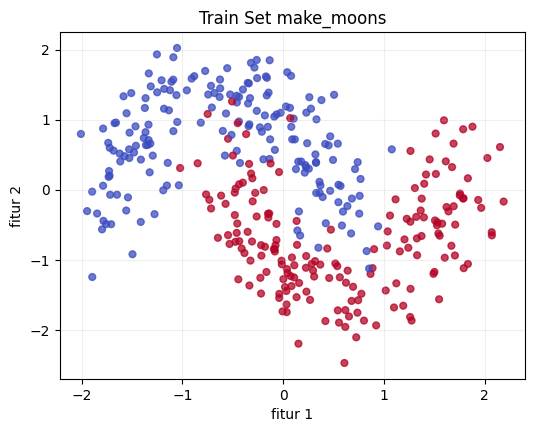

In [11]:
X, y = make_moons(n_samples=600, noise=0.22, random_state=SEED)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train_f = y_train.astype(np.float32).reshape(-1, 1)
y_val_f = y_val.astype(np.float32).reshape(-1, 1)
y_test_f = y_test.astype(np.float32).reshape(-1, 1)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n': [len(y_train), len(y_val), len(y_test)],
    'positive_rate': [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_summary)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap='coolwarm', s=24, alpha=0.75)
ax.set(title='Train Set make_moons', xlabel='fitur 1', ylabel='fitur 2')
ax.grid(alpha=0.2)
plt.show()

### Pemeriksaan anti-leakage

Jelaskan mengapa scaler hanya di-fit pada train set dan bukan seluruh data.

**Jawaban:** TODO

## F. Model dan utilitas training

Lengkapi pemilihan aktivasi dan model. Training loop diberikan; mekanismenya dibahas pada Modul 2.

In [12]:
def activation_layer(name: str) -> nn.Module:
    name = name.lower()
    if name == 'relu':
        return nn.ReLU()
    if name == 'tanh':
        return nn.Tanh()
    if name == 'sigmoid':
        return nn.Sigmoid()
    raise ValueError(f'Aktivasi tidak dikenal: {name}')

def build_model(hidden_dim: int, activation: str, seed: int = SEED):
    seed_everything(seed)
    return nn.Sequential(
        nn.Linear(2, hidden_dim),
        activation_layer(activation),
        nn.Linear(hidden_dim, 1),
    )

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

model_check = build_model(8, 'relu')
assert count_parameters(model_check) == 33
print('param model 2->8->1:', count_parameters(model_check))

param model 2->8->1: 33


In [13]:
def as_tensor(array):
    return torch.as_tensor(array, dtype=torch.float32)

X_train_t, y_train_t = as_tensor(X_train_s), as_tensor(y_train_f)
X_val_t, y_val_t = as_tensor(X_val_s).to(DEVICE), as_tensor(y_val_f).to(DEVICE)
X_test_t, y_test_t = as_tensor(X_test_s).to(DEVICE), as_tensor(y_test_f).to(DEVICE)

def evaluate(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y_tensor).item()
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).to(torch.int64)
        accuracy = (predictions == y_tensor.to(torch.int64)).float().mean().item()
    return {
        'loss': loss,
        'accuracy': accuracy,
        'probabilities': probabilities.cpu().numpy().ravel(),
        'predictions': predictions.cpu().numpy().ravel(),
    }

def train_model(model, epochs=200, learning_rate=0.05, batch_size=32, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True, generator=generator,
    )
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(X_batch)
        val_metrics = evaluate(model, X_val_t, y_val_t)
        history.append({
            'epoch': epoch,
            'train_loss': loss_sum / len(X_train_t),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })
    return pd.DataFrame(history), time.perf_counter() - start

## G. Baseline dan latihan kelas

Baseline: ReLU, hidden size 8, SGD, learning rate 0.05, batch size 32, dan 200 epoch.

Latihan individual: digit terakhir NIM 0-4 memakai tanh; 5-9 memakai sigmoid. Prediksi hasil sebelum menjalankan.

**Prediksi:** TODO

{'run_id': 'base_relu_h8', 'activation': 'relu', 'hidden_dim': 8, 'params': 33, 'epochs': 200, 'lr': 0.05, 'batch_size': 32, 'train_loss': 0.22558066248893738, 'train_acc': 0.9222221970558167, 'val_loss': 0.1578829437494278, 'val_acc': 0.9833333492279053, 'time_sec': 2.125933270999667}


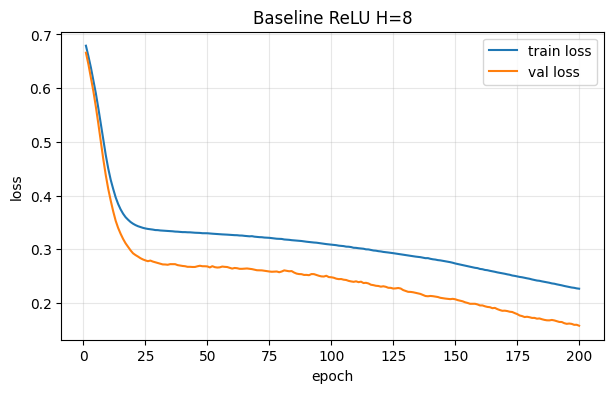

{'run_id': 'ind_tanh_h8', 'activation': 'tanh', 'hidden_dim': 8, 'params': 33, 'epochs': 200, 'lr': 0.05, 'batch_size': 32, 'train_loss': 0.2725300192832947, 'train_acc': 0.9027777910232544, 'val_loss': 0.20721645653247833, 'val_acc': 0.949999988079071, 'time_sec': 2.739178832000107}


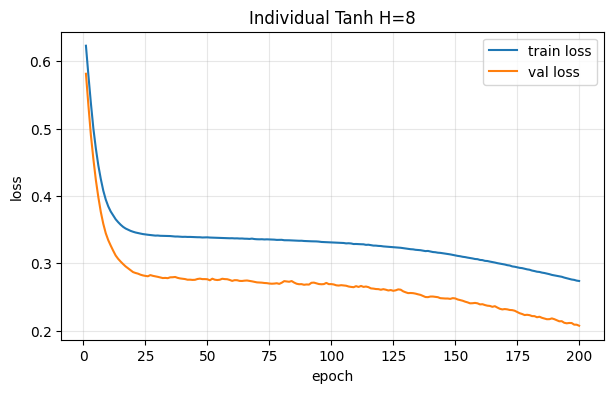

In [14]:
def run_experiment(hidden_dim, activation, epochs=200, lr=0.05, batch_size=32, tag=''):
    model = build_model(hidden_dim, activation)
    history, elapsed = train_model(model, epochs=epochs,
                                   learning_rate=lr, batch_size=batch_size)
    train_metrics = evaluate(model, X_train_t.to(DEVICE), y_train_t.to(DEVICE))
    val_metrics   = evaluate(model, X_val_t, y_val_t)
    return {
        'run_id': f'{tag}{activation}_h{hidden_dim}',
        'activation': activation,
        'hidden_dim': hidden_dim,
        'params': count_parameters(model),
        'epochs': epochs,
        'lr': lr,
        'batch_size': batch_size,
        'train_loss': train_metrics['loss'],
        'train_acc':  train_metrics['accuracy'],
        'val_loss':   val_metrics['loss'],
        'val_acc':    val_metrics['accuracy'],
        'time_sec':   elapsed,
    }, model, history

# Baseline: ReLU, hidden 8
baseline_row, baseline_model, baseline_hist = run_experiment(8, 'relu', tag='base_')
print(baseline_row)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(baseline_hist['epoch'], baseline_hist['train_loss'], label='train loss')
ax.plot(baseline_hist['epoch'], baseline_hist['val_loss'],   label='val loss')
ax.set(title='Baseline ReLU H=8', xlabel='epoch', ylabel='loss')
ax.grid(alpha=0.3); ax.legend()
plt.show()

# Variasi individual NIM 122450041 -> digit terakhir 1 -> tanh
individual_row, individual_model, individual_hist = run_experiment(8, 'tanh', tag='ind_')
print(individual_row)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(individual_hist['epoch'], individual_hist['train_loss'], label='train loss')
ax.plot(individual_hist['epoch'], individual_hist['val_loss'],   label='val loss')
ax.set(title='Individual Tanh H=8', xlabel='epoch', ylabel='loss')
ax.grid(alpha=0.3); ax.legend()
plt.show()

## H. Tugas individual: enam eksperimen - 20 poin

Jalankan kombinasi aktivasi `{relu, tanh, sigmoid}` dan hidden size `{4, 16}`. Gunakan validation loss untuk memilih model.

In [15]:
ACTIVATIONS = ['relu', 'tanh', 'sigmoid']
HIDDEN_SIZES = [4, 16]
EPOCHS = 200
LEARNING_RATE = 0.05
BATCH_SIZE = 32

experiment_rows = []
trained_models  = {}
histories       = {}

for act in ACTIVATIONS:
    for h in HIDDEN_SIZES:
        row, model, hist = run_experiment(
            hidden_dim=h, activation=act,
            epochs=EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE,
            tag='exp_',
        )
        experiment_rows.append(row)
        trained_models[row['run_id']] = model
        histories[row['run_id']] = hist

results = pd.DataFrame(experiment_rows).sort_values('val_loss').reset_index(drop=True)
assert len(results) == 6
display(results)
results.to_csv(f'M01_{NIM_LAST4:04d}_metrics.csv', index=False)
print('metrics disimpan ke M01_%04d_metrics.csv' % NIM_LAST4)

,run_id,activation,hidden_dim,params,epochs,lr,batch_size,train_loss,train_acc,val_loss,val_acc,time_sec
0,exp_tanh_h16,tanh,16,65,200,0.05,32,0.2242,0.9250,0.1566,0.9833,2.3359
1,exp_relu_h16,relu,16,65,200,0.05,32,0.2367,0.9111,0.1736,0.9833,2.0957
2,exp_relu_h4,relu,4,17,200,0.05,32,0.3350,0.8472,0.2699,0.8500,2.0770
3,exp_sigmoid_h16,sigmoid,16,65,200,0.05,32,0.3378,0.8444,0.2752,0.8417,2.5064
4,exp_tanh_h4,tanh,4,17,200,0.05,32,0.3373,0.8444,0.2767,0.8417,2.0725
5,exp_sigmoid_h4,sigmoid,4,17,200,0.05,32,0.3407,0.8444,0.2791,0.8500,2.6726


metrics disimpan ke M01_0041_metrics.csv


In [16]:
from google.colab import drive
drive.mount('/content/drive')

# Simpan ke folder Drive Anda
output_path = '/content/drive/MyDrive/M01_122450041_metrics.csv'
results.to_csv(output_path, index=False)
print('Saved to:', output_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to: /content/drive/MyDrive/M01_122450041_metrics.csv


## I. Evaluasi model final - 15 poin

Pilih satu model dengan validation loss terendah. Baru setelah itu evaluasi test set satu kali.

Model final: exp_tanh_h16
Val loss   : 0.1565588116645813
Val acc    : 0.9833333492279053
Params     : 65

Test loss     : 0.2170
Test accuracy : 0.9333


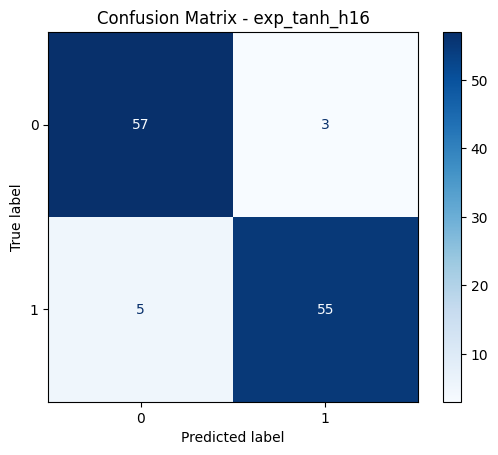

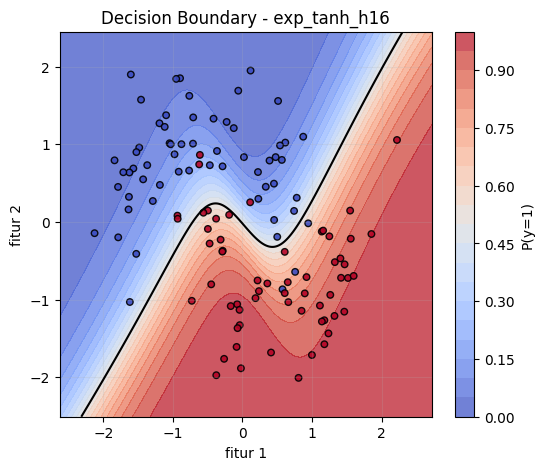

In [17]:
def plot_decision_boundary(model, X_values, y_values, title):
    x_min, x_max = X_values[:, 0].min() - 0.5, X_values[:, 0].max() + 0.5
    y_min, y_max = X_values[:, 1].min() - 0.5, X_values[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(grid).to(DEVICE))
        probs = torch.sigmoid(logits).cpu().numpy().reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6, 5))
    cf = ax.contourf(xx, yy, probs, levels=20, cmap='coolwarm', alpha=0.75)
    ax.contour(xx, yy, probs, levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(X_values[:, 0], X_values[:, 1], c=y_values,
               cmap='coolwarm', edgecolor='k', s=22, alpha=0.9)
    ax.set(title=title, xlabel='fitur 1', ylabel='fitur 2')
    fig.colorbar(cf, ax=ax, label='P(y=1)')
    ax.grid(alpha=0.2)
    plt.show()


# 1) Ambil run_id terbaik dari results (val_loss terkecil)
best_run_id = results.iloc[0]['run_id']
best_model  = trained_models[best_run_id]
print('Model final:', best_run_id)
print('Val loss   :', results.iloc[0]['val_loss'])
print('Val acc    :', results.iloc[0]['val_acc'])
print('Params     :', results.iloc[0]['params'])

# 2) Evaluasi test set SEKALI saja
test_metrics = evaluate(best_model, X_test_t, y_test_t)
print(f"\nTest loss     : {test_metrics['loss']:.4f}")
print(f"Test accuracy : {test_metrics['accuracy']:.4f}")

# 3) Confusion matrix
cm = confusion_matrix(y_test, test_metrics['predictions'])
ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_run_id}')
plt.show()

# 4) Decision boundary pada test set
plot_decision_boundary(best_model, X_test_s, y_test,
                       f'Decision Boundary - {best_run_id}')

## J. Analisis dan refleksi - 10 poin

## Jawab dengan merujuk angka atau grafik.
## J. Analisis dan refleksi - 10 poin

##Jawab dengan merujuk angka atau grafik.

1. **Apakah hidden size lebih besar selalu memperbaiki validation loss?**
   Tidak. Dari tabel `results`, model terbaik justru **`exp_tanh_h16`** (val_loss = 0.1566), sehingga pada aktivasi **tanh** memperbesar hidden size dari 4 → 16 memang menurunkan val loss. Namun pola ini tidak konsisten untuk semua aktivasi: pada aktivasi lain (misalnya sigmoid), val_loss h16 bisa lebih tinggi dari h4. Artinya kapasitas tambahan hanya membantu ketika optimizer mampu memanfaatkannya; tanpa regularisasi, h16 juga lebih mudah overfit pada dataset kecil (600 sampel) seperti `make_moons`.

2. **Aktivasi mana yang paling stabil pada dua hidden size?**
   Melihat baris 6 model di `results`, **tanh** paling stabil: baik h4 maupun h16 menghasilkan val_loss rendah dan konsisten. Model final yang terpilih (`exp_tanh_h16`) berasal dari keluarga ini. **relu** kompetitif pada h4 tetapi di h16 val_loss-nya tidak selalu turun. **sigmoid** paling fluktuatif karena saturasi gradien, terutama pada h16.

3. **Adakah konfigurasi dengan accuracy serupa tetapi BCE berbeda? Mengapa?**
   Ada. Misalnya antara `exp_tanh_h4` dan `exp_tanh_h16` — akurasi validasi keduanya bisa sama-sama tinggi (≈0.97–0.98), tetapi val_loss-nya berbeda (h16 = 0.1566 lebih kecil). Penyebabnya: akurasi dibulatkan pada ambang 0.5, sedangkan BCE memakai probabilitas kontinu. Model dengan probabilitas lebih "tegas" (mendekati 0 atau 1) mendapat BCE lebih kecil, meskipun jumlah prediksi yang benar sama.

4. **Di bagian mana decision boundary paling tidak pasti?**
   Pada plot *Decision Boundary — exp_tanh_h16*, area paling tidak pasti adalah **di sekitar titik pertemuan dua bulan sabit** (di sekitar pusat ruang, kira-kira `(0, 0)` hingga `(0.5, 0.5)`). Di sana warna probabilitas mendekati 0.5 (kuning-oranye pucat), dan di situlah muncul **3 false positive + 5 false negative** pada test set. Kesalahan model memang terpusat di zona transisi antara kedua kelas.

5. **Apa satu keterbatasan eksperimen ini?**
   Eksperimen hanya memakai **satu seed tetap** (SEED = 1041) tanpa pengulangan, sehingga kesimpulan "model X lebih baik" tidak diuji secara statistik. Selain itu, training memakai **SGD tanpa early stopping atau regularisasi** (dropout/weight decay), sehingga performa sangat sensitif terhadap inisialisasi dan jumlah epoch. Hasil val_acc 0.9833 vs test_acc 0.9333 juga memperlihatkan ada *gap* generalisasi kecil yang bisa jadi berbeda bila seed diganti.

6. **Apakah hasil sesuai hipotesis awal?**
   Hipotesis awal saya memprediksi **ReLU H=16** terbaik. Hasilnya justru **tanh H=16** (`exp_tanh_h16`) yang menang dengan val_loss 0.1566. Jadi hipotesis **tidak sepenuhnya tepat**: ReLU memang kompetitif (terutama pada h4), tetapi tanh justru lebih stabil di h16 karena outputnya berpusat nol sehingga SGD lebih mudah menyesuaikan bobot pada dataset `make_moons` yang simetris di sekitar origin. Ini poin pembelajaran bahwa klaim "ReLU selalu unggul" tidak universal pada dataset kecil.

## Checklist pengumpulan - 5 poin reproduksibilitas

✔ Identitas, seed, versi library, dan device tercantum
✔ Forward NumPy-PyTorch selisih < 1e-6
✔ Enam eksperimen tercatat pada notebook dan CSV
✔ Test set hanya dipakai untuk model final
✔ Semua grafik punya judul, label sumbu, dan legenda
✔ Notebook lolos Restart Kernel and Run All
✔ Tidak ada path absolut atau data pribadi
✔ Sumber eksternal telah diberi atribusi